<a href="https://colab.research.google.com/github/praneshnikhar/Machinelearning/blob/main/linearregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np

In [28]:
class Linear_Regression():

  def __init__(self, learning_rate, no_of_iterations):
    self.learning_rate = learning_rate
    self.no_of_iterations = no_of_iterations

  def fit(self, X , Y):
    #number of training examples and number of features
    self.m, self.n = X.shape #number of rows and columns
    self.w = np.zeros(self.n)
    self.b = 0
    self.X = X
    self.Y = Y

    #implementing gradient descent

    for i in range(self.no_of_iterations):
      self.update_weights()



  def update_weights(self):

    Y_prediction = self.predict(self.X)
    #calculate the gradient

    dw = - (2*(self.X.T).dot(self.Y - Y_prediction)) /self.m

    db = - 2 * np.sum(self.Y - Y_prediction)/self.m

    #updating the weights

    self.w = self.w - self.learning_rate * dw
    self.b = self.b - self.learning_rate * db

  def predict(self, X):
    return X.dot(self.w) + self.b



In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [7]:
#loading the data from csv file to a pandas dataframe

salary_data = pd.read_csv('/content/salary_data.csv')

In [8]:
salary_data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [9]:
salary_data.shape

(30, 2)

In [10]:
salary_data.isnull().sum()

,0
YearsExperience,0
Salary,0


In [11]:
X = salary_data.iloc[:,:-1]
Y = salary_data.iloc[:,1].values

In [33]:
X_train, X_test, Y_train , Y_test = train_test_split(X,Y, test_size=0.33, random_state=2)

In [34]:
model = Linear_Regression(learning_rate= 0.02, no_of_iterations = 1000)

In [35]:
model.fit(X_train,Y_train)

In [36]:
print('weight = ', model.w[0])
print('bias = ', model.b)

weight =  9514.400999035135
bias =  23697.406507136307


<ipython-input-36-d3a472053b8c>:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('weight = ', model.w[0])


In [38]:
test_data_prediction = model.predict(X_test)

In [39]:
print(test_data_prediction)

1      36066.127806
0      34163.247606
14     66512.211003
9      58900.690204
21     91249.653600
19     80783.812501
23    101715.494699
6      52240.609504
3      42726.208505
20     88395.333301
dtype: float64


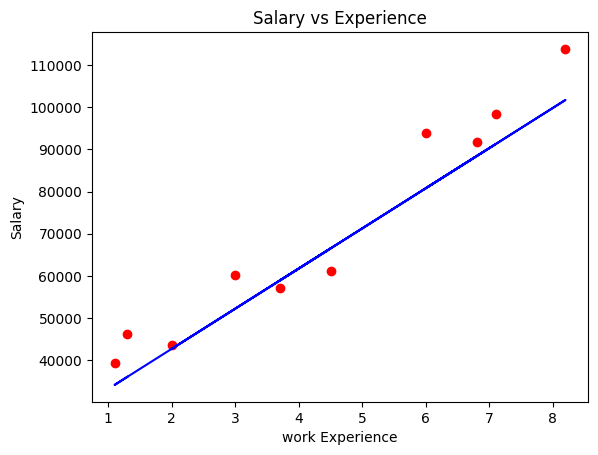

In [41]:
 plt.scatter(X_test, Y_test, color = 'red')
 plt.plot(X_test, test_data_prediction, color = 'blue')
 plt.xlabel('work Experience')
 plt.ylabel('Salary')
 plt.title('Salary vs Experience')
 plt.show()